# Global Superstore -- Exploratory Data Analysis

Exploratory Data Analysis on the Global Superstore dataset (51290 order records, 25 original features), identifying factors is why do some orders/products/regions lose money instead of making it. Dataset source: Global Superstone dataset (Kaggle).

## Executive Summary


## Module 2: Data Understanding

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df= pd.read_csv("..\data\Global_Superstore.csv", encoding="latin1")

In [3]:
df.shape


(51290, 24)

In [4]:
df.memory_usage(deep=True).sum()/1024

np.float64(53894.37890625)

In [5]:
df.head() 

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,28-01-2013,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,05-11-2013,06-11-2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  object 
 2   Order Date      51290 non-null  object 
 3   Ship Date       51290 non-null  object 
 4   Ship Mode       51290 non-null  object 
 5   Customer ID     51290 non-null  object 
 6   Customer Name   51290 non-null  object 
 7   Segment         51290 non-null  object 
 8   City            51290 non-null  object 
 9   State           51290 non-null  object 
 10  Country         51290 non-null  object 
 11  Postal Code     9994 non-null   float64
 12  Market          51290 non-null  object 
 13  Region          51290 non-null  object 
 14  Product ID      51290 non-null  object 
 15  Category        51290 non-null  object 
 16  Sub-Category    51290 non-null  object 
 17  Product Name    51290 non-null 

In [7]:
df.isna().sum()

Row ID                0
Order ID              0
Order Date            0
Ship Date             0
Ship Mode             0
Customer ID           0
Customer Name         0
Segment               0
City                  0
State                 0
Country               0
Postal Code       41296
Market                0
Region                0
Product ID            0
Category              0
Sub-Category          0
Product Name          0
Sales                 0
Quantity              0
Discount              0
Profit                0
Shipping Cost         0
Order Priority        0
dtype: int64

In [8]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit,Shipping Cost
count,51290.00000,9994.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,25645.50000,55190.379428,246.490581,3.476545,0.142908,28.610982,26.375915
std,14806.29199,32063.693350,487.565361,2.278766,0.212280,174.340972,57.296804
min,1.00000,1040.000000,0.444000,1.000000,0.000000,-6599.978000,0.000000
25%,12823.25000,23223.000000,30.758625,2.000000,0.000000,0.000000,2.610000
50%,25645.50000,56430.500000,85.053000,3.000000,0.000000,9.240000,7.790000
75%,38467.75000,90008.000000,251.053200,5.000000,0.200000,36.810000,24.450000
max,51290.00000,99301.000000,22638.480000,14.000000,0.850000,8399.976000,933.570000


In [9]:
df.describe(include='object') 

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,Country,Market,Region,Product ID,Category,Sub-Category,Product Name,Order Priority
count,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290
unique,25035,1430,1464,4,1590,795,3,3636,1094,147,7,13,10292,3,17,3788,4
top,CA-2014-100111,18-06-2014,22-11-2014,Standard Class,PO-18850,Muhammed Yedwab,Consumer,New York City,California,United States,APAC,Central,OFF-AR-10003651,Office Supplies,Binders,Staples,Medium
freq,14,135,130,30775,97,108,26518,915,2001,9994,11002,11117,35,31273,6152,227,29433


In [10]:
df.duplicated().sum()
#No duplicates found 

np.int64(0)

In [11]:
print(df.nunique().sort_values())
#id column is Row Id so here we will make it as index 

Segment               3
Category              3
Ship Mode             4
Order Priority        4
Market                7
Region               13
Quantity             14
Sub-Category         17
Discount             27
Country             147
Postal Code         631
Customer Name       795
State              1094
Order Date         1430
Ship Date          1464
Customer ID        1590
City               3636
Product Name       3788
Shipping Cost     10037
Product ID        10292
Sales             22995
Profit            24575
Order ID          25035
Row ID            51290
dtype: int64


## Data Understanding — Summary

- Dataset contains 51,290 rows and 24 columns, with no duplicate rows.
- `Postal Code` is the only column with missing values — 41,296 out of 51,290 rows 
  (~80.5%) are missing, likely because this dataset spans multiple global markets 
  and postal codes are only populated for a subset of countries. Given this scale 
  of missingness, the column will be dropped entirely in Module 3 rather than 
  imputed.
- No constant columns in this — every column has more than one unique value, so there's nothing to drop purely for lack of information.
- `Row ID` is a pure identifier — 51,290 unique values for 51,290 rows — and will 
  be set as the index rather than treated as a feature.
- `Order ID` has 25,035 unique values despite 51,290 rows, meaning many rows share 
  the same Order ID — this makes sense, since a single order can contain multiple 
  line items (different products), so Order ID is not a per-row identifier the 
  way Row ID is.
- Categorical columns are mostly low-cardinality (Segment: 3, Category: 3, Ship 
  Mode: 4, Order Priority: 4, Market: 7, Region: 13, Sub-Category: 17), which will 
  make bar/count plots clean and readable. `Country` (147) and `State` (1,094), by 
  contrast, are high-cardinality and will need top-N filtering for any visualization.
- Overall, this dataset is much larger and structurally different from the HR 
  dataset — the main cleaning action ahead is dropping `Postal Code`, setting the 
  index, and correcting data types, rather than handling duplicates or constants.

## Module 3: Data Cleaning . 

In [12]:
#since it is having 80% of null values so we cannot fill it just we will drop 
df= df.drop(columns='Postal Code')

In [13]:
df = df.set_index('Row ID')

In [14]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [15]:
categorical_cols = ['Ship Mode', 'Segment', 'Category', 'Sub-Category', 
                     'Market', 'Region', 'Order Priority']
for col in  categorical_cols : 
    df[col]=df[col].astype('category')

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51290 entries, 32298 to 6147
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        51290 non-null  object        
 1   Order Date      51290 non-null  datetime64[ns]
 2   Ship Date       51290 non-null  datetime64[ns]
 3   Ship Mode       51290 non-null  category      
 4   Customer ID     51290 non-null  object        
 5   Customer Name   51290 non-null  object        
 6   Segment         51290 non-null  category      
 7   City            51290 non-null  object        
 8   State           51290 non-null  object        
 9   Country         51290 non-null  object        
 10  Market          51290 non-null  category      
 11  Region          51290 non-null  category      
 12  Product ID      51290 non-null  object        
 13  Category        51290 non-null  category      
 14  Sub-Category    51290 non-null  category      
 15  Prod

In [17]:
df['Shipping Duration'] = (df['Ship Date'] - df['Order Date']).dt.days

In [18]:
df[['Sales', 'Profit', 'Discount', 'Shipping Cost', 'Shipping Duration']].describe()

,Sales,Profit,Discount,Shipping Cost,Shipping Duration
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,246.490581,28.610982,0.142908,26.375915,3.969370
std,487.565361,174.340972,0.212280,57.296804,1.729437
min,0.444000,-6599.978000,0.000000,0.000000,0.000000
25%,30.758625,0.000000,0.000000,2.610000,3.000000
50%,85.053000,9.240000,0.000000,7.790000,4.000000
75%,251.053200,36.810000,0.200000,24.450000,5.000000
max,22638.480000,8399.976000,0.850000,933.570000,7.000000


In [19]:
df.dtypes

Order ID                     object
Order Date           datetime64[ns]
Ship Date            datetime64[ns]
Ship Mode                  category
Customer ID                  object
Customer Name                object
Segment                    category
City                         object
State                        object
Country                      object
Market                     category
Region                     category
Product ID                   object
Category                   category
Sub-Category               category
Product Name                 object
Sales                       float64
Quantity                      int64
Discount                    float64
Profit                      float64
Shipping Cost               float64
Order Priority             category
Shipping Duration             int64
dtype: object

In [20]:
df.shape


(51290, 23)

In [21]:
df.to_csv('../data/superstore_cleaned.csv')

## Data Cleaning — Summary

- Dropped `Postal Code` (~80.5% missing) and set `Row ID` as the index, reducing 
  the dataframe from 24 to 23 working columns.
- Converted `Order Date` and `Ship Date` to proper datetime types, and converted 
  low-cardinality categorical columns (Ship Mode, Segment, Category, Sub-Category, 
  Market, Region, Order Priority) to `category` dtype.
- Derived a new `Shipping Duration` column (Ship Date − Order Date, in days) to 
  enable delivery-time analysis in later modules.
- Ran a range sanity-check on the key numeric columns and confirmed no impossible 
  values: `Sales` has no zero/negative entries (min ≈ 0.44), `Discount` stays 
  within the expected 0–0.85 range, `Shipping Cost` is non-negative, and 
  `Shipping Duration` ranges from 0 to 7 days with no negative values — meaning 
  no order was shipped before it was placed.
- `Profit` ranges from about −6,600 to 8,400, confirming a meaningful number of 
  orders are sold at a loss. This is treated as real business data, not an error, 
  and is worth exploring further in bivariate analysis (e.g., which categories 
  or markets drive losses).
- Saved the cleaned dataframe to `superstore_cleaned.csv` for use in subsequent modules.

## Module - 04: Univariate Analysis

In [25]:
df = pd.read_csv('../data/superstore_cleaned.csv', index_col='Row ID', 
                  parse_dates=['Order Date', 'Ship Date'])
df.shape

(51290, 23)

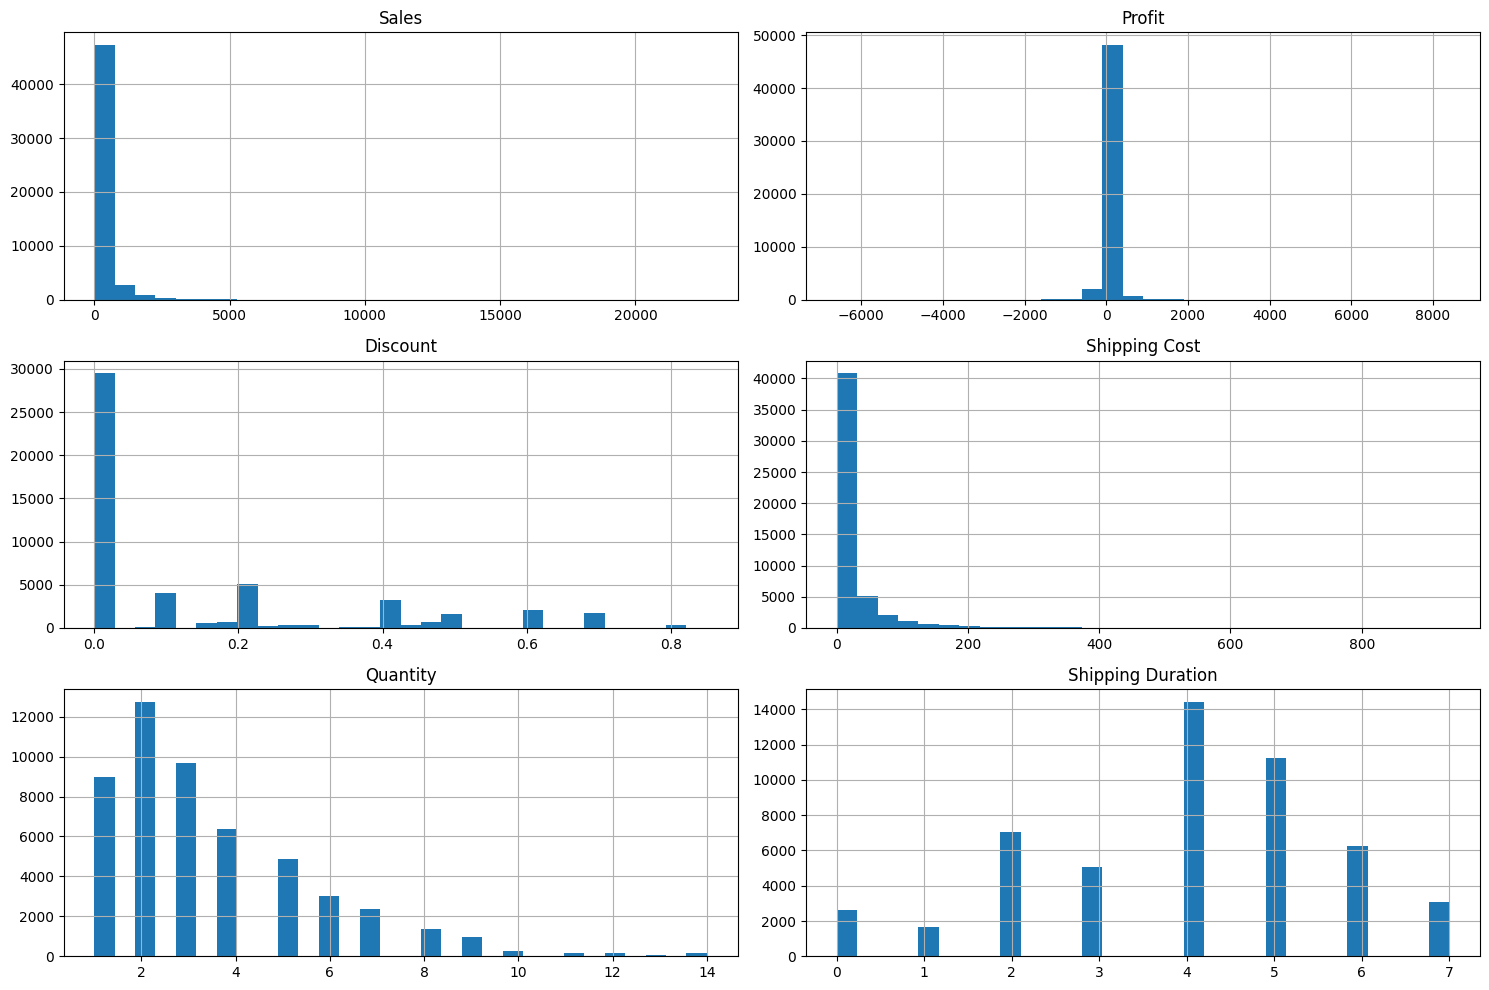

In [27]:
continuous_cols = ['Sales', 'Profit', 'Discount', 'Shipping Cost', 
                    'Quantity', 'Shipping Duration']

df[continuous_cols].hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

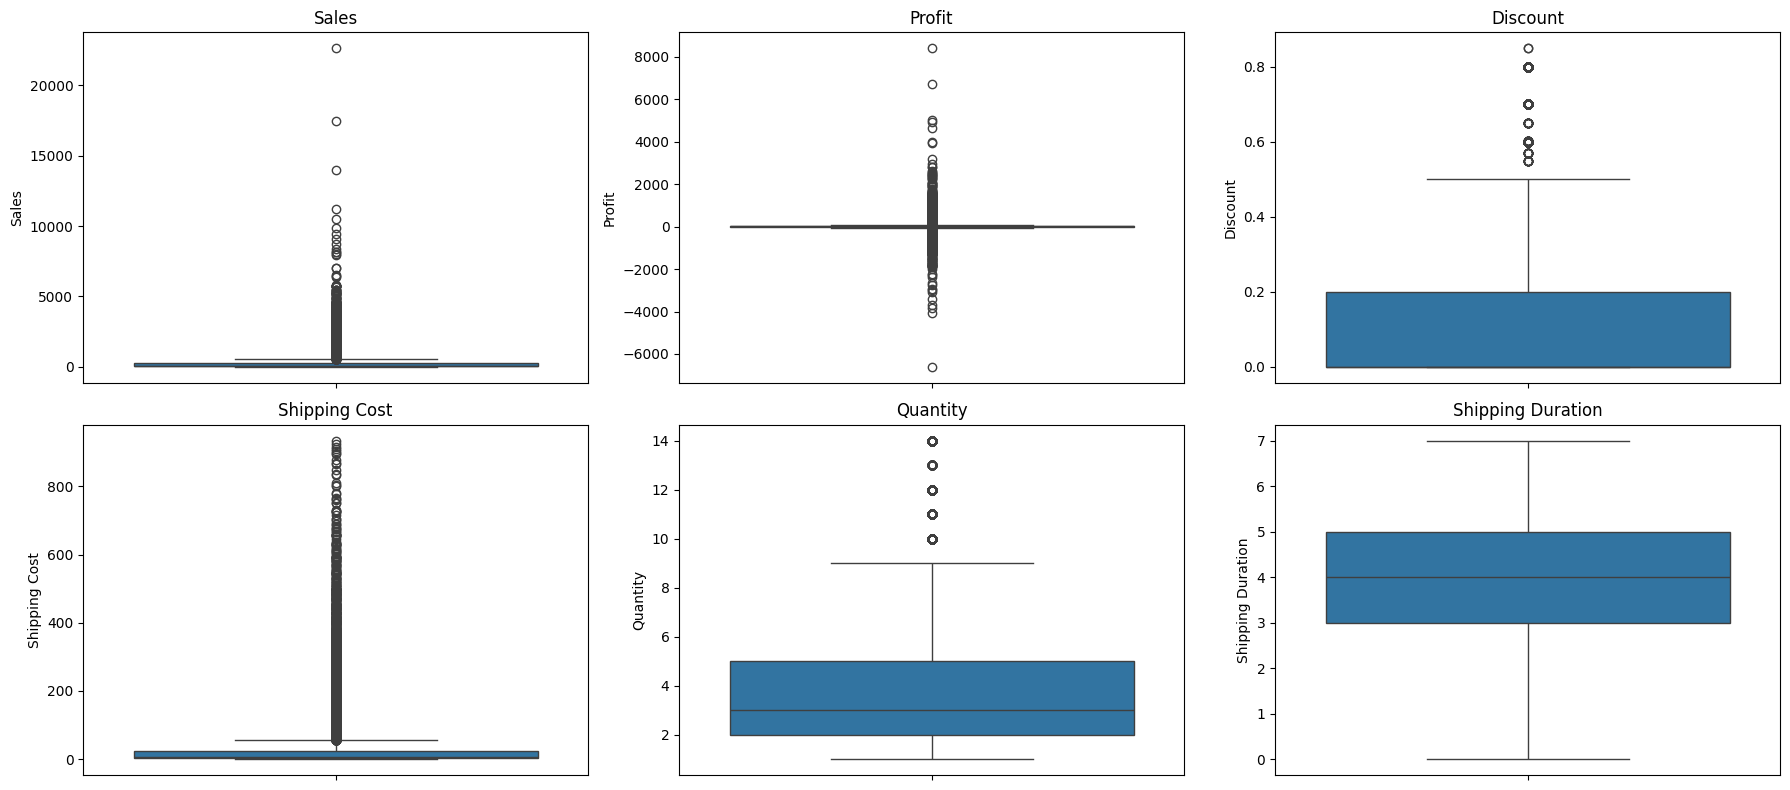

In [37]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, col in zip(axes.flatten(), continuous_cols):
    sns.boxplot(data=df, y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [39]:
df[continuous_cols].skew().sort_values(ascending=False)

Sales                8.138080
Shipping Cost        5.863226
Profit               4.157189
Discount             1.387775
Quantity             1.360368
Shipping Duration   -0.432053
dtype: float64

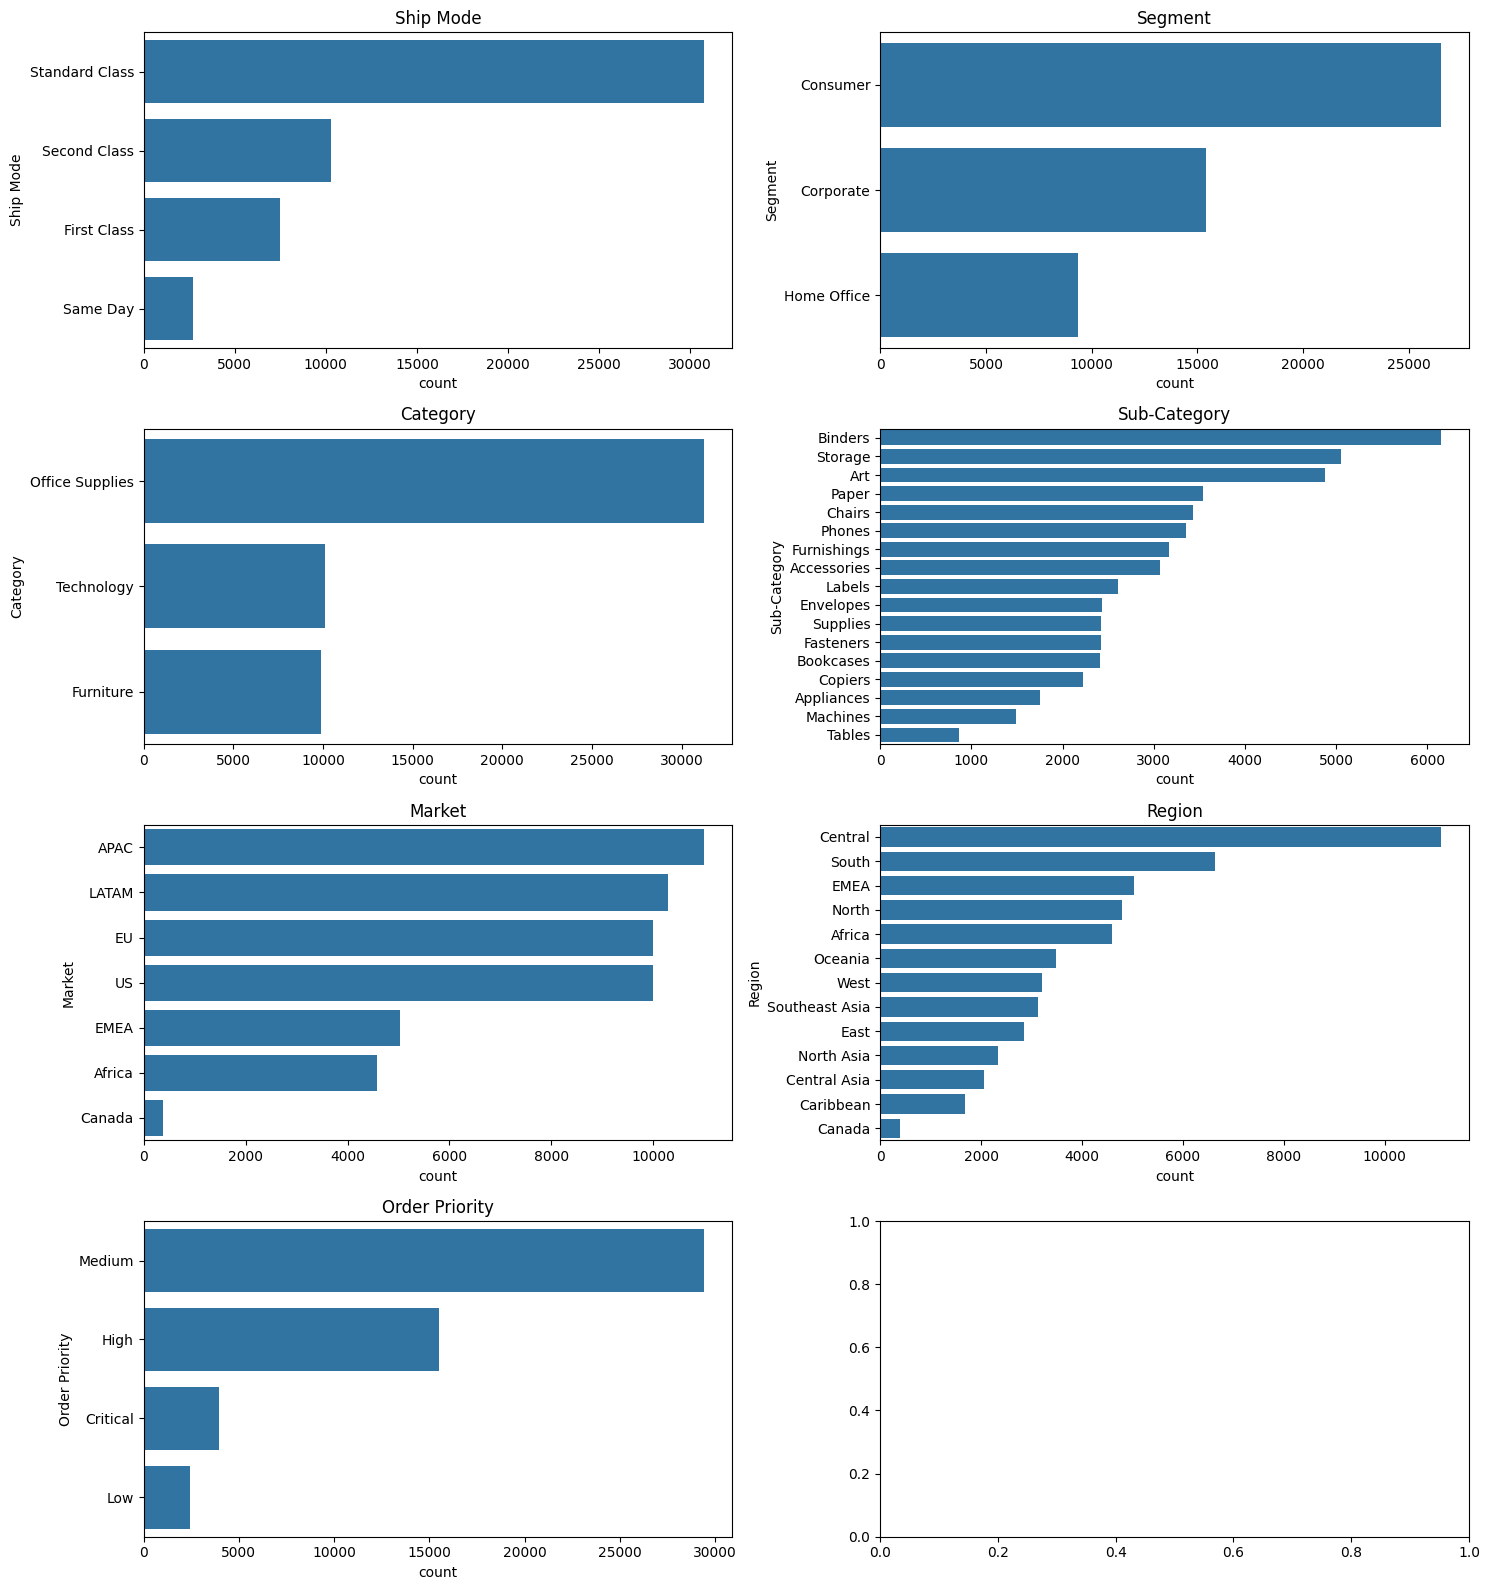

In [42]:
categorical_cols = ['Ship Mode', 'Segment', 'Category', 'Sub-Category', 
                     'Market', 'Region', 'Order Priority']

fig, axes = plt.subplots(4, 2, figsize=(15, 16))
for ax, col in zip(axes.flatten(), categorical_cols):
    sns.countplot(data=df, y=col, ax=ax, order=df[col].value_counts().index)
    ax.set_title(col)
plt.tight_layout()
plt.show()


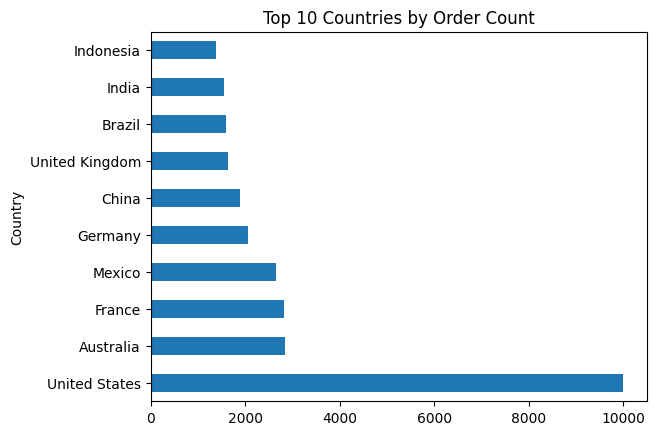

In [ ]:
df['Country'].value_counts().head(10).plot(kind='barh')
plt.title('Top 10 Countries by Order Count')
plt.show() 

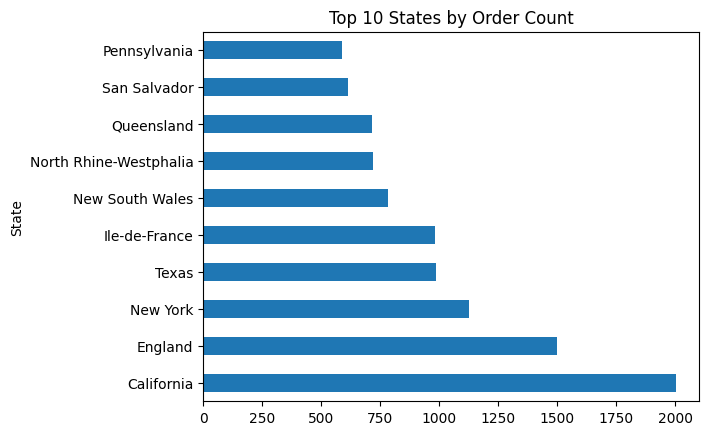

In [44]:
df['State'].value_counts().head(10).plot(kind='barh')
plt.title('Top 10 States by Order Count')
plt.show()

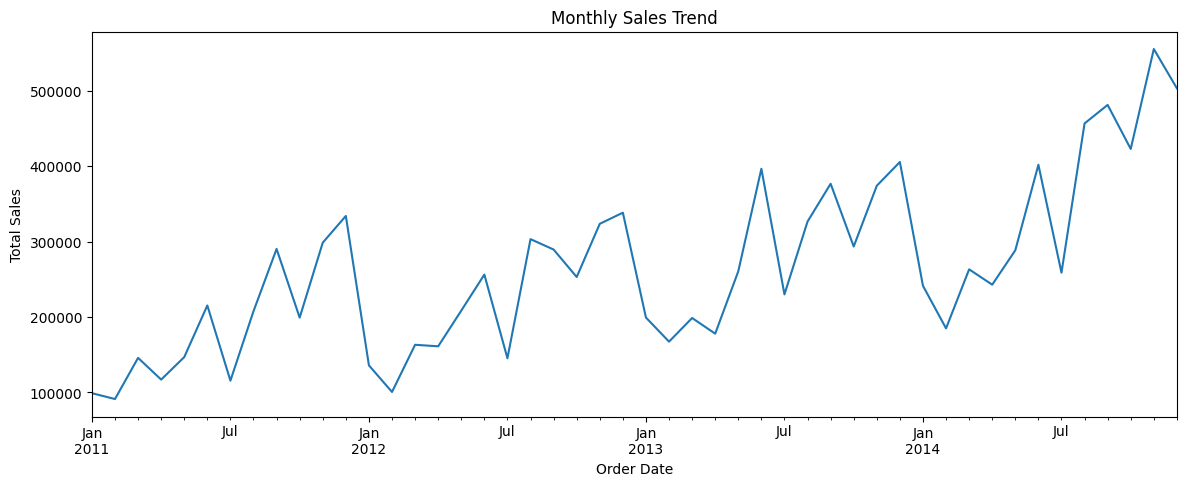

In [45]:
df.set_index('Order Date')['Sales'].resample('M').sum().plot(figsize=(14,5))
plt.title('Monthly Sales Trend')
plt.ylabel('Total Sales')
plt.show()

## Univariate Analysis — Summary

- **Skewness confirms heavy right-skew** for `Sales` (8.14), `Shipping Cost` (5.86), 
  and `Profit` (4.16) — these are the most extreme, driven by a small number of 
  very large orders/costs and some very large losses. `Discount` (1.39) and 
  `Quantity` (1.36) are moderately skewed. `Shipping Duration` (-0.43) is close 
  to symmetric, with a slight lean toward longer durations.
- **Outliers are concentrated in the same three columns** — the boxplots for 
  `Sales`, `Profit`, and `Shipping Cost` all show dense clusters of points 
  extending well beyond the whiskers on both ends (high-value orders, large 
  losses, and expensive shipments). `Discount` shows a handful of outliers above 
  0.5, and `Quantity` has some orders above 9 units. `Shipping Duration`, by 
  contrast, shows no real outliers — it stays cleanly within its 0-7 day range.
- **Ship Mode and Category are both heavily dominated by one option each** — 
  Standard Class accounts for the large majority of shipments (~30k of 51k+ 
  orders), far ahead of Second Class, First Class, and Same Day. Similarly, 
  Office Supplies dominates Category (~31k orders), more than three times 
  Technology or Furniture (~10k each) — `Binders` is the single largest 
  Sub-Category.
- **Segment is more evenly split** — Consumer leads (~26k) but Corporate (~15k) 
  and Home Office (~9k) both have meaningful representation, unlike the sharp 
  dominance seen in Ship Mode and Category.
- **Monthly sales show a clear upward trend with strong seasonality** — total 
  sales grew from roughly ~100k/month in early 2011 to consistently 400k-550k/
  month by late 2014, with a recurring pattern of year-end spikes (Nov/Dec) 
  each year before dipping again in January — suggesting a seasonal, holiday-
  driven sales cycle layered on top of overall business growth.